# 1. Exploratory Data Analysis (EDA)

In this notebook, we initialize our data pipeline using the `DataLoader` and perform a comprehensive health check on the dataset.

In [1]:
import sys
import os
import pandas as pd

# Add the 'src' directory to the Python path so we can import data_loader
sys.path.append(os.path.abspath('..'))

from src.data_loader import DataLoader

## Load the Dataset

In [2]:
DATA_PATH = '../data/raw/merged_jee_cutoff_2018_2025.csv'
loader = DataLoader(DATA_PATH)

# Load the uncleaned data to perform our health check
df = loader.load_data()

Loading data from ../data/raw/merged_jee_cutoff_2018_2025.csv...
Data successfully loaded. Shape: (Rows, Columns) (433993, 9)



In [4]:
df.head()

,Institute,Academic Program Name,Quota,Seat Type,Gender,Opening Rank,Closing Rank,Round,Year
0,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OPEN,Gender-Neutral,5057.0,6780.0,1,2018
1,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OPEN,Female-only (including Supernumerary),10078.0,10789.0,1,2018
2,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OBC-NCL,Gender-Neutral,1649.0,2592.0,1,2018
3,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OBC-NCL,Female-only (including Supernumerary),4343.0,4522.0,1,2018
4,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,SC,Gender-Neutral,1054.0,1233.0,1,2018


## 1. Missing Values per Column
Let's see exactly how many missing values exist in the raw dataset before cleaning.

In [6]:
missing_values = df.isnull().sum()
# Display only columns that have missing values
missing_values[missing_values > 0]

Academic Program Name       1
Quota                       1
Seat Type                   2
Gender                      3
Opening Rank             1468
Closing Rank             1469
dtype: int64

## 2. Check for Duplicate Rows
Duplicate rows can skew the model's understanding of probabilities by over-representing certain outcomes. We must identify them.

In [3]:
duplicate_count = df.duplicated().sum()
print(f"Number of exact duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    # Show a sample of the duplicates to understand why they occurred
    display(df[df.duplicated(keep=False)].sort_values(by=['Institute', 'Academic Program Name', 'Year']).head(6))

Number of exact duplicate rows: 0


## 3. Statistical Summary of Ranks
We need to check the `Opening Rank` and `Closing Rank` to ensure there are no data entry anomalies, such as negative ranks or ranks equal to 0.

In [8]:
# Filter to numerical columns to avoid pandas warnings
rank_stats = df[['Opening Rank', 'Closing Rank']].describe()
display(rank_stats)

# Check for invalid ranks (<= 0)
invalid_ranks = df[(df['Opening Rank'] <= 0) | (df['Closing Rank'] <= 0)]
print(f"\nNumber of rows with rank <= 0: {len(invalid_ranks)}")

,Opening Rank,Closing Rank
count,4.325250e+05,4.325240e+05
mean,1.091298e+04,1.378077e+04
std,3.120640e+04,4.163089e+04
min,1.000000e+00,1.000000e+00
25%,1.218000e+03,1.485000e+03
50%,3.783000e+03,4.555000e+03
75%,1.010400e+04,1.221700e+04
max,1.274910e+06,1.368129e+06



Number of rows with rank <= 0: 0


## 4. Distribution of Closing Ranks by Seat Type
Visualizing the distribution of target variables is essential. We use boxplots to observe the spread, medians, and outliers of closing ranks for each category. This helps us confirm our intuition that certain quotas have drastically different rank distributions.

C:\Users\Rupam\AppData\Local\Temp\ipykernel_3816\1704560587.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Seat Type', y='Closing Rank', data=plot_df, palette='Set2')


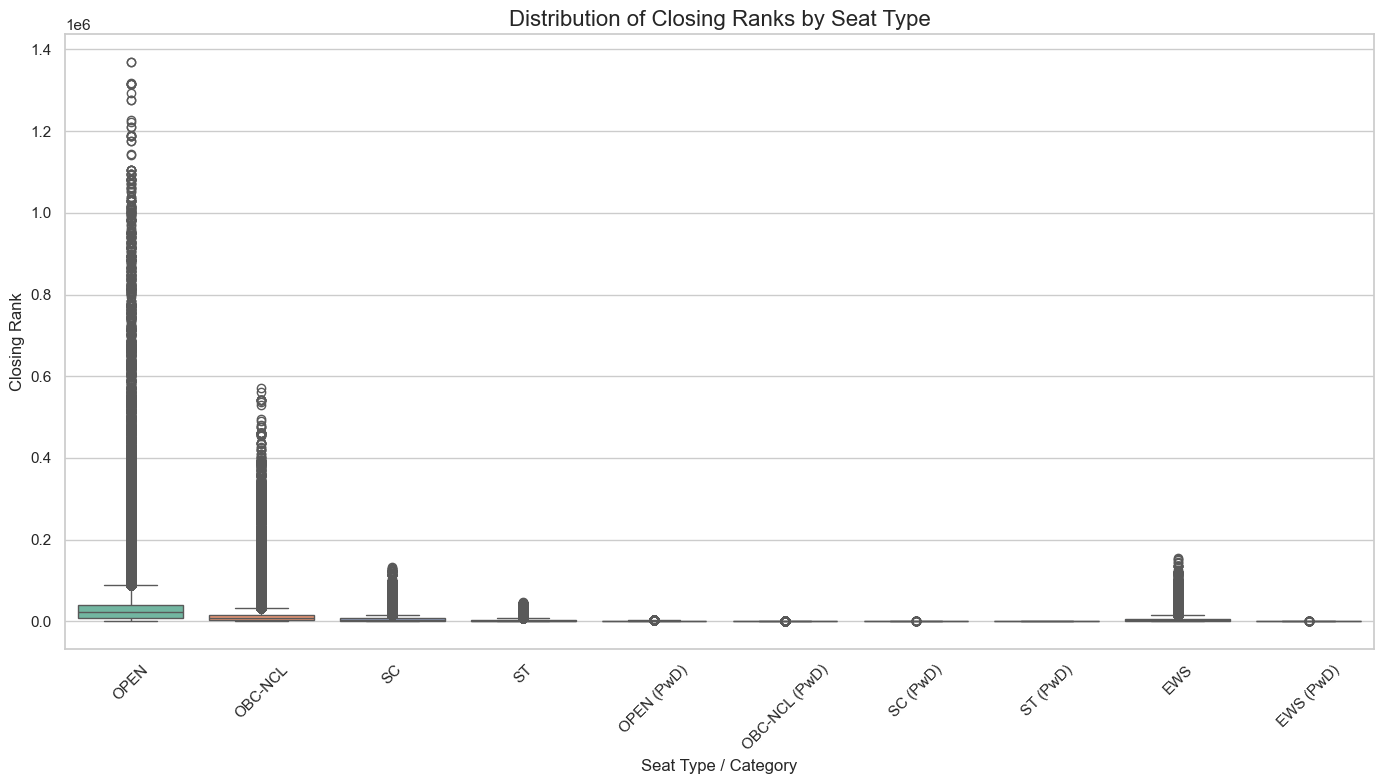

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

# Create a figure
plt.figure(figsize=(14, 8))

# Boxplot for Closing Rank by Seat Type
# We drop NaNs in Closing Rank for the visualization to avoid plotting errors
plot_df = df.dropna(subset=['Closing Rank'])

sns.boxplot(x='Seat Type', y='Closing Rank', data=plot_df, palette='Set2')

plt.title('Distribution of Closing Ranks by Seat Type', fontsize=16)
plt.xlabel('Seat Type / Category', fontsize=12)
plt.ylabel('Closing Rank', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
df["Academic Program Name"].value_counts()  # gives the no of rows for each unique Academic Program in sorted order
df["Academic Program Name"].value_counts().head().index

Index(['Computer Science and Engineering (4 Years, Bachelor of Technology)',
       'Electronics and Communication Engineering (4 Years, Bachelor of Technology)',
       'Mechanical Engineering (4 Years, Bachelor of Technology)',
       'Civil Engineering (4 Years, Bachelor of Technology)',
       'Electrical Engineering (4 Years, Bachelor of Technology)'],
      dtype='str', name='Academic Program Name')

## 5. Year-on-Year Trend (Inflation vs Deflation)
We want to observe how the `Closing Rank` changes across different years for the top 5 most popular programs. If the trend is flat, `Year` might not be an important feature. If the ranks are shifting consistently (e.g., CSE cutoffs getting stricter), the model *must* use `Year` as a weighted feature to capture the timeline.

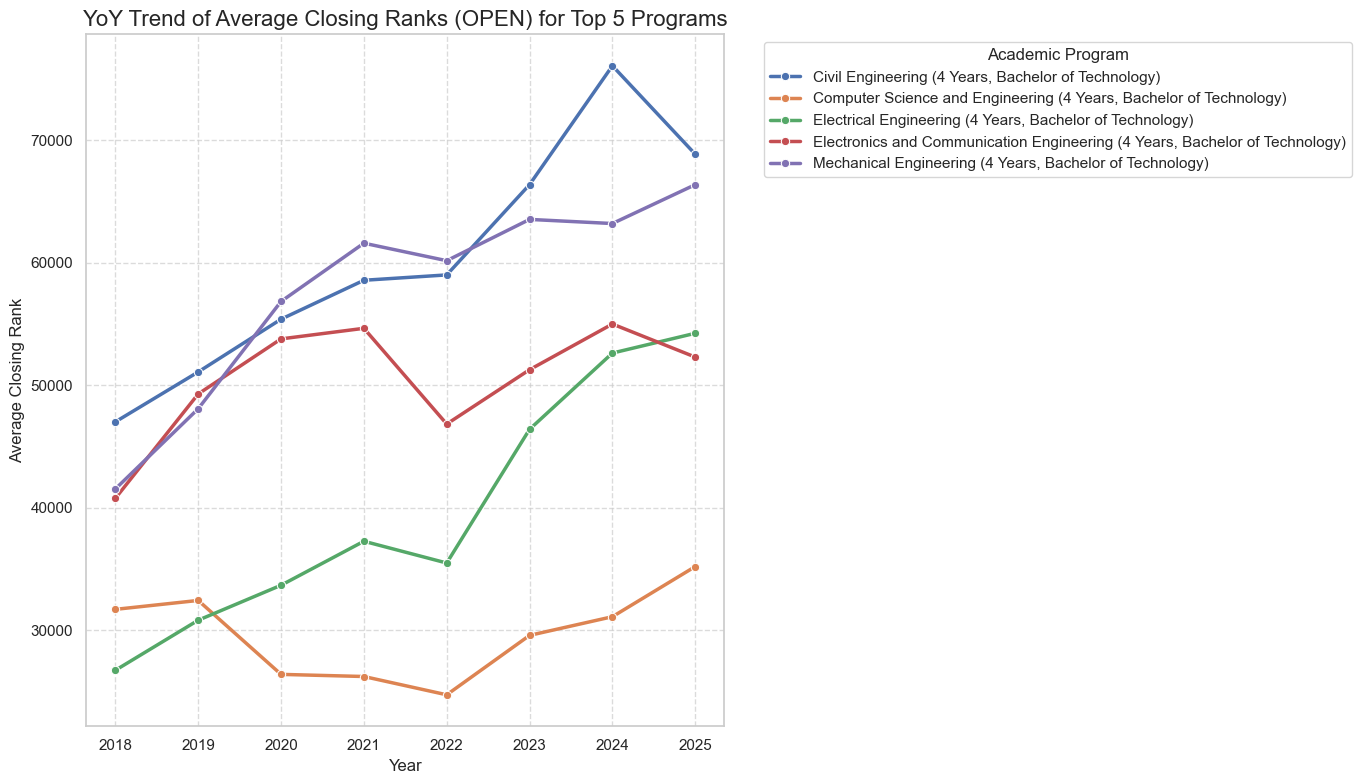

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Identify the top 5 most common Academic Programs
top_5_programs = df['Academic Program Name'].value_counts().head(5).index

# 2. Filter the dataframe to only include these top 5 programs
trend_df = df[df['Academic Program Name'].isin(top_5_programs)].copy()

# 3. We filter to 'OPEN' Seat Type for a clean baseline trend to avoid skew from different quotas
trend_df = trend_df[trend_df['Seat Type'] == 'OPEN']

# 4. Calculate the average Closing Rank per year for each program
yearly_trend = trend_df.groupby(['Year', 'Academic Program Name'])['Closing Rank'].mean().reset_index()

# 5. Plot the trend
plt.figure(figsize=(14, 8))
sns.lineplot(data=yearly_trend, x='Year', y='Closing Rank', hue='Academic Program Name', marker='o', linewidth=2.5)

plt.title('YoY Trend of Average Closing Ranks (OPEN) for Top 5 Programs', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Closing Rank', fontsize=12)
# Move legend outside the plot so it doesn't overlap lines
plt.legend(title='Academic Program', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()